<a href="https://colab.research.google.com/github/Kristina-aut/my-pet-project/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BA%D0%B0_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%B8_%D0%B2%D0%B8%D0%B7%D1%83%D0%B0%D0%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pip install pandas openpyxl

In [ ]:
orders = pd.read_excel('/content/orders.xlsx')

In [ ]:
products = pd.read_excel('/content/products.xlsx')

In [ ]:
orders

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130
...,...,...,...,...,...,...,...
3318,1517405750,2022-01-13 19:29:44,79337,2,105,105,54
3319,1517676281,2022-01-13 08:21:53,79337,1,105,105,54
3320,1517545392,2022-01-13 13:16:21,11897,1,513,513,392
3321,1517658904,2022-01-13 08:50:25,6392,2,79,79,45


In [ ]:
products

,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio
...,...,...,...,...
40147,112937,Безалкогольные напитки,Напитки,Напиток Venom
40148,112997,Бакалея,Пряности,Приправа Adjika Family
40149,113057,Бакалея,Пряности,Соль Кулина
40150,113117,Кулинария,Готовые блюда,Салат Хлеб Насущный


In [ ]:
df = pd.merge(orders, products, on = 'product_id', how = 'left')

In [ ]:
result = df.groupby('level1', as_index=False)['quantity'].sum()
result.columns = ['Категория', 'Количество проданных штук']
print(result)

                       Категория  Количество проданных штук
0                        Бакалея                        239
1         Безалкогольные напитки                        534
2                  Бытовая химия                         23
3                        Гигиена                         77
4                Детское питание                         96
5       Детство (Гигиена и Уход)                          6
6         Замороженная продукция                        175
7           Кондитерские изделия                        138
8      Консервированные продукты                         74
9                    Кофе, какао                         21
10                     Кулинария                        250
11            Молочная продукция                        483
12   Мучные кондитерские изделия                        124
13            Мясная гастрономия                        112
14                          Мясо                         29
15        Продукция для животных        

In [ ]:
result.to_excel('sales_by_category.xlsx', index=False)

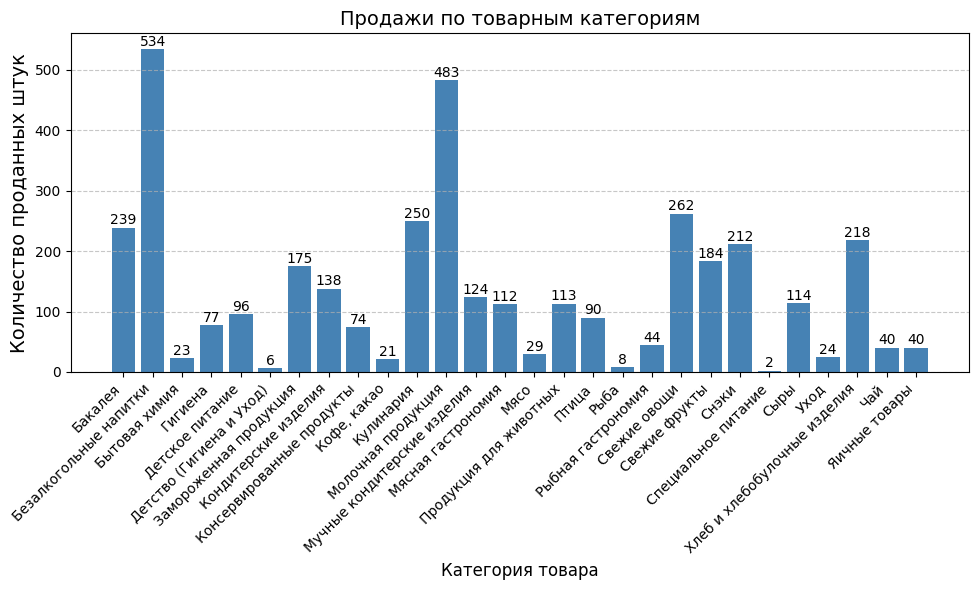

In [ ]:
plt.figure(figsize=(10, 6))
bars = plt.bar(result['Категория'], result['Количество проданных штук'], color='steelblue')
plt.xlabel('Категория товара', fontsize=12)
plt.ylabel('Количество проданных штук', fontsize=14)
plt.title('Продажи по товарным категориям', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
  height = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
           f'{int(height)}', ha = 'center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
pivot = df.pivot_table(
    index='level1',
    columns='level2',
    values='quantity',
    aggfunc='sum',
    fill_value=0
)
pivot['Итого по категории'] = pivot.sum(axis=1)
pivot = pivot.sort_values('Итого по категории', ascending=False)
pivot_pct = pivot.div(pivot['Итого по категории'], axis=0) * 100
pivot_pct = pivot_pct.round(1)
pivot_pct.columns = [f'{col}(%)' for col in pivot_pct.columns]
print("=== Абсолютные значения (количество проданных штук) ===")
print(pivot)

print("\n=== Доли внутри категорий (в %) ===")
print(pivot_pct)

=== Абсолютные значения (количество проданных штук) ===
level2                        Бананы, косточковые и прочие плоды  \
level1                                                             
Безалкогольные напитки                                         0   
Молочная продукция                                             0   
Свежие овощи                                                   0   
Кулинария                                                      0   
Бакалея                                                        0   
Хлеб и хлебобулочные изделия                                   0   
Снэки                                                          0   
Свежие фрукты                                                 76   
Замороженная продукция                                         0   
Кондитерские изделия                                           0   
Мучные кондитерские изделия                                    0   
Сыры                                                        

In [ ]:
df['accepted_at'] = pd.to_datetime(df['accepted_at'])
target_date = '2022-01-13'
mask = df['accepted_at'].dt.date == pd.to_datetime(target_date).date()
orders_day = df[mask].copy()
if orders_day.empty:
  print(f"За {target_date} нет заказов.")
else:
  orders_day['revenue'] = orders_day['quantity'] * orders_day['price']
  check_sums = orders_day.groupby('order_id')['revenue'].sum()
  avg_check = check_sums.mean()
  print(f"Средний чек на {target_date}: {avg_check:.2f} руб.")

Средний чек на 2022-01-13: 915.64 руб.


In [ ]:
print(f"Количество чеков за 13 января 2022 год: {len(check_sums)}")

Количество чеков за 13 января 2022 год: 544


In [ ]:
cheese_products = products[products['level2'].str.contains('сыр', na=False)]
cheese_product_ids = set(cheese_products['product_id'])
cheese_orders = df[df['product_id'].isin(cheese_product_ids)]
promo_orders = cheese_orders.groupby('product_id')['price'].min() < cheese_orders.groupby('product_id')['regular_price'].min()
promo_mask = cheese_orders.groupby('product_id').apply(
    lambda group: (group['price'] < group['regular_price']).any()
)
promo_product_ids = set(promo_mask[promo_mask].index)
total_sold = set(cheese_orders['product_id'])
total_count = len(total_sold)
promo_count = len(promo_product_ids)
if total_count > 0:
  share = promo_count / total_count
  print(f"Всего продавалось товаров в категории 'сыры': {total_count}")
  print(f"Из них по промоакции: {promo_count}")
  print(f"Доля товаров с промо-продажами: {share:.2%}")
else:
  print("В категории 'сыры' нет проданных товаров.")


Всего продавалось товаров в категории 'сыры': 48
Из них по промоакции: 16
Доля товаров с промо-продажами: 33.33%


/tmp/ipykernel_6315/578924259.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  promo_mask = cheese_orders.groupby('product_id').apply(


In [ ]:
import matplotlib.pyplot as plt

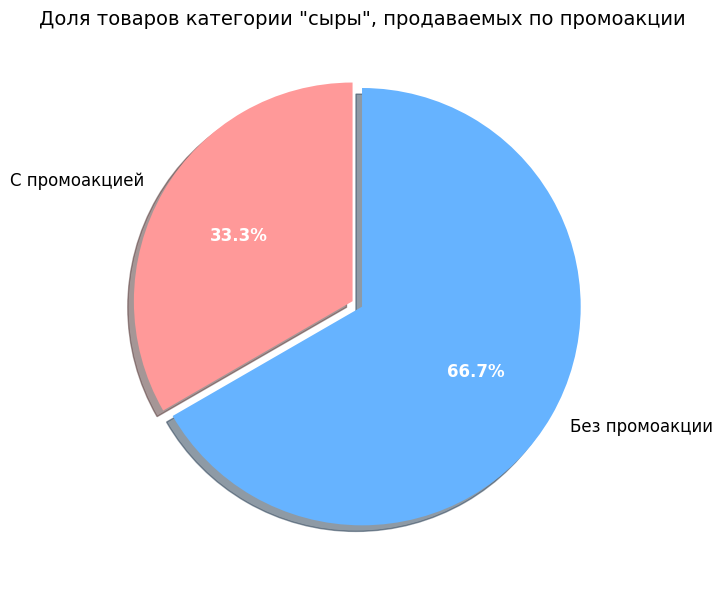

In [ ]:
no_promo_count = total_count - promo_count
if total_count > 0:
  labels = ['С промоакцией', 'Без промоакции']
  sizes = [promo_count, no_promo_count]
  colors = ['#ff9999', '#66b3ff']
  explode = (0.05, 0)

  plt.figure(figsize=(8, 6))
  patches, texts, autotexts = plt.pie(
      sizes,
      labels=labels,
      autopct='%1.1f%%',
      startangle=90,
      colors=colors,
      explode=explode,
      shadow=True,
      textprops={'fontsize': 12}
  )
  for autotext in autotexts:
      autotext.set_color('white')
      autotext.set_fontweight('bold')
  plt.title('Доля товаров категории "сыры", продаваемых по промоакции', fontsize=14)
  plt.tight_layout()
  plt.show()
else:
  print("Нет проданных товаров в категории'сыры' для построения диаграммы")

In [ ]:
df['revenue'] = df['quantity'] * df['price']
df['cost'] = df['quantity'] * df['cost_price']
df['margin_rub'] = df['revenue'] - df['cost']

margin_by_cat = df.groupby('level1', as_index=False).agg(
    total_revenue = ('revenue', 'sum'),
    total_cost = ('cost', 'sum'),
    total_margin_rub = ('margin_rub', 'sum')
)

In [ ]:

margin_by_cat['margin_percent'] = margin_by_cat['total_margin_rub'] / margin_by_cat['total_revenue']
margin_by_cat['margin_percent'] = margin_by_cat['margin_percent'].round(2)

margin_by_cat['total_revenue'] = margin_by_cat['total_revenue'].round(2)
margin_by_cat['total_cost'] = margin_by_cat['total_cost'].round(2)
margin_by_cat['total_margin_rub'] = margin_by_cat['total_margin_rub'].round(2)

margin_by_cat = margin_by_cat.sort_values('margin_percent', ascending=False)

margin_by_cat.columns = ['Категория', 'Выручка (руб)', 'Себестоимость (руб)', 'Маржа (руб)', 'Маржа (%)']
print("=== Маржинальность по категориям ===")
print(margin_by_cat.to_string(index=False))

=== Маржинальность по категориям ===
                   Категория  Выручка (руб)  Себестоимость (руб)  Маржа (руб)  Маржа (%)
                 Кофе, какао           9761                 4702         5059       0.52
         Специальное питание            410                  202          208       0.51
      Замороженная продукция          27714                14615        13099       0.47
                         Чай           6413                 3484         2929       0.46
                   Кулинария          40840                22388        18452       0.45
 Мучные кондитерские изделия          13904                 7621         6283       0.45
      Безалкогольные напитки          46107                25734        20373       0.44
                       Снэки          22477                12895         9582       0.43
        Кондитерские изделия          13942                 8024         5918       0.42
Хлеб и хлебобулочные изделия          14724                 8473         

In [ ]:
df['revenue'] = df['quantity'] * df['price']
df['cost'] = df['quantity'] * df['cost_price']
df['margin_rub'] = df['revenue'] - df['cost']

margin_by_cat = df.groupby('level1', as_index=False).agg(
    total_revenue = ('revenue', 'sum'),
    total_cost = ('cost', 'sum'),
    total_margin_rub = ('margin_rub', 'sum')
)

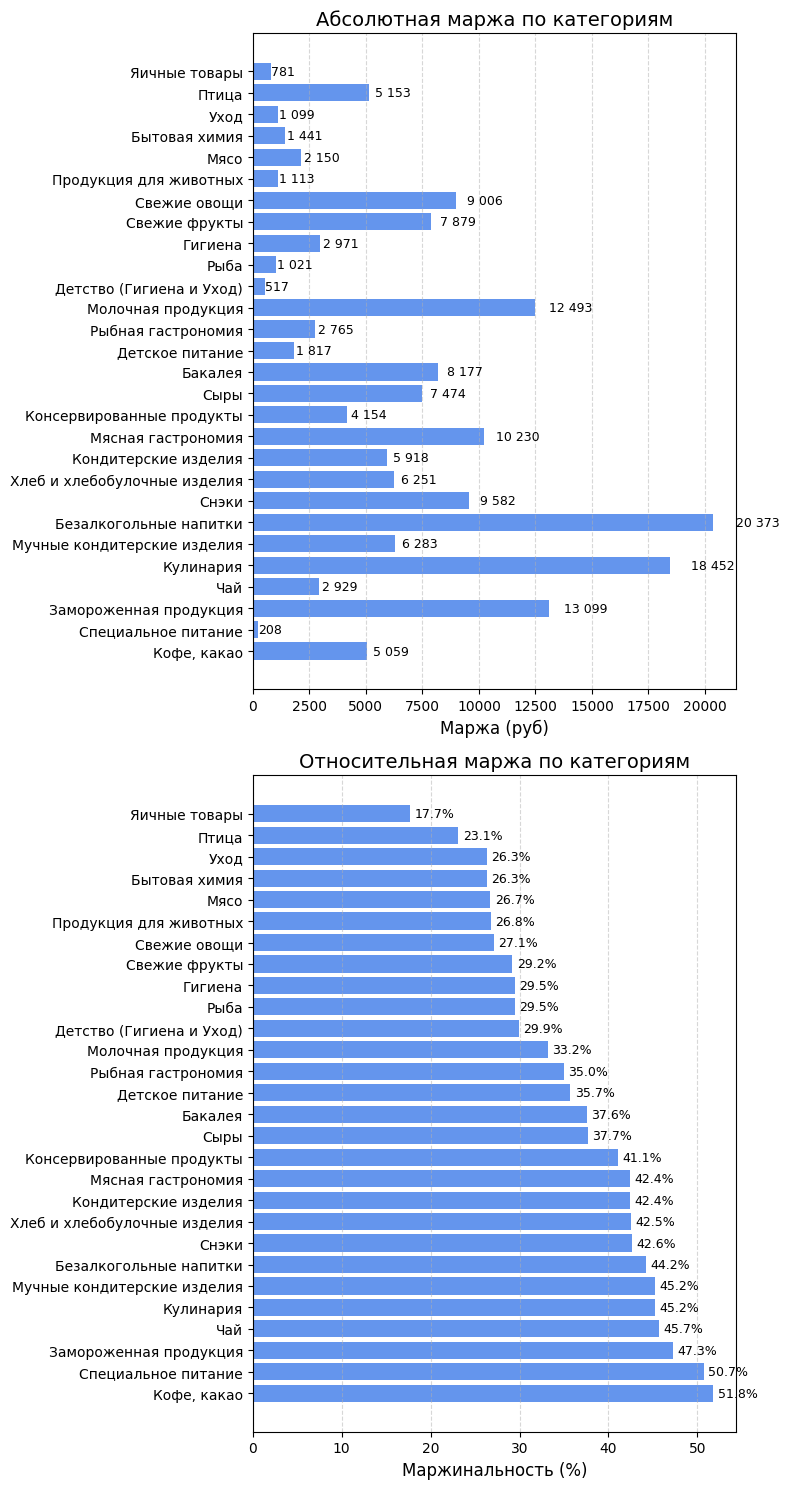

In [ ]:
margin_by_cat['margin_percent'] = (margin_by_cat['total_margin_rub'] / margin_by_cat['total_revenue'])*100
margin_by_cat['margin_percent'] = margin_by_cat['margin_percent'].round(1)

margin_by_cat = margin_by_cat.sort_values('margin_percent', ascending=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 15))
bars1 = ax1.barh(margin_by_cat['level1'], margin_by_cat['total_margin_rub'], color='cornflowerblue')
ax1.set_xlabel('Маржа (руб)', fontsize=12)
ax1.set_title('Абсолютная маржа по категориям', fontsize=14)
ax1.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars1:
  width = bar.get_width()
  ax1.text(width + width*0.05, bar.get_y() + bar.get_height()/2,
           f'{int(width):,}'.replace(',', ' '),
           ha='left', va='center', fontsize=9)

bars2 = ax2.barh(margin_by_cat['level1'], margin_by_cat['margin_percent'], color='cornflowerblue')

ax2.set_xlabel('Маржинальность (%)', fontsize=12)
ax2.set_title('Относительная маржа по категориям', fontsize=14)
ax2.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%',
             ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
from typing import ValuesView
product_sales = df.groupby('product_id').agg(
    total_qty=('quantity', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()

In [ ]:
def abc_class(series):
  sorted_series = series.sort_values(ascending=False)
  total = sorted_series.sum()
  cumsum = sorted_series.cumsum() / total * 100
  classes = []
  for val in cumsum:
      if val <= 80:
          classes.append('A')
      elif val <= 95:
          classes.append('B')
      else:
          classes.append('C')
  return pd.Series(classes, index=sorted_series.index)

product_sales['class_qty'] = product_sales.set_index('product_id')["total_qty"].pipe(abc_class).values
product_sales['class_rev'] = product_sales.set_index('product_id')['total_revenue'].pipe(abc_class).values

def priority_class(row):
  if 'A' in (row['class_qty'], row['class_rev']):
      return 'A'
  elif 'B' in (row['class_qty'], row['class_rev']):
      return 'B'
  else:
      return 'C'

product_sales['class_priority'] = product_sales.apply(priority_class, axis=1)

df = pd.merge(df, product_sales[['product_id', 'class_priority']], on='product_id', how='left')

print(df[['order_id', 'product_id', 'quantity', 'price', 'revenue', 'class_priority']].head(10))

     order_id  product_id  quantity  price  revenue class_priority
0  1517514900       17122         1    169      169              B
1  1517430051       17122         1    169      169              B
2  1517578174       17122         1    169      169              B
3  1517466327       22199         1    219      219              B
4  1517429157       22199         1    219      219              B
5  1517416615       22199         1    219      219              B
6  1517577392       22199         1    219      219              B
7  1517443550        3414         6     27      162              A
8  1517623373        3414         3     27       81              A
9  1517496176       47819         1    119      119              B
